# Tweeting Fear: Trump Tweets × Market Volatility
### BUSN 20800 Big Data — Proposal Notebook
**Hewitt Watkins, Erik Lopez, Mateo Fretes, Vedant Dangayach**

This notebook produces all summary statistics and regressions needed for the project proposal.

**To run:** upload `trump_tweets_dataset.csv` to your Colab session (or set `TWEETS_PATH` below), add your FRED API key, then `Runtime → Run All`.


## 0. Install & Import

In [1]:
# Run once in Colab
!pip install vaderSentiment fredapi yfinance statsmodels -q


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings, re
warnings.filterwarnings('ignore')

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import statsmodels.api as sm
from scipy import stats

# ── Plotting style ──
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130, "axes.titlesize": 12, "axes.labelsize": 10})
print("Imports OK")


Imports OK


## 1. Configuration — set your paths & API key here

In [3]:
# ── USER SETTINGS ─────────────────────────────────────────────────────────
TWEETS_PATH = "trump_tweets_dataset.csv"
FRED_API_KEY = "beeed973495d94c208c342e754c75413"

# Full date window: Twitter first term + Truth Social through Jan 2026
START       = "2017-01-20"
END         = "2026-01-08"

# Temporal train/test split
TRAIN_END   = "2023-12-31"   # train: 2017–2023 (Twitter + early Truth Social)
TEST_START  = "2024-01-01"   # test:  2024–2026 (Truth Social, out-of-sample)
# ──────────────────────────────────────────────────────────────────────────

## 2. Load & Clean Tweets

In [4]:
df = pd.read_csv(TWEETS_PATH)
print(f"Raw rows: {len(df):,}")

# Parse dates
df['date'] = pd.to_datetime(df['date'], utc=True, errors='coerce')
df = df.dropna(subset=['date', 'text'])

# Keep original posts only (no reposts/quotes), all platforms, full date range
df = df[
    (df['repost_flag'] == False) &
    (df['quote_flag']  == False) &
    (df['date'] >= START)
].copy()

df = df.sort_values('date').reset_index(drop=True)
print(f"After filtering (original posts only, all platforms, {START}–present): {len(df):,} posts")
print("Platform breakdown:")
print(df['platform'].value_counts().to_string())
print()
print(f"Date range: {df['date'].min().date()} → {df['date'].max().date()}")
print(df[['date','platform','text','favorite_count','repost_count']].head(3).to_string())

Raw rows: 90,554
After filtering (original posts only, all platforms, 2017-01-20–present): 41,502 posts
Platform breakdown:
platform
Truth Social    24503
Twitter         16999

Date range: 2017-01-20 → 2026-01-08
                       date platform                                                                                                                                                              text  favorite_count  repost_count
0 2017-01-20 00:40:51+00:00  Twitter  Thank you for joining us at the Lincoln Memorial tonight- a very special evening! Together, we are going to MAKE AMERICA GREAT AGAIN! pic.twitter.com/5d774OCx5o          146346         28852
1 2017-01-20 04:24:33+00:00  Twitter                                                                    Thank you for a wonderful evening in Washington, D.C. #Inauguration pic.twitter.com/a6xpFQTHj5           98164         17221
2 2017-01-20 12:31:53+00:00  Twitter                                                  It all begins

## 3. Feature Engineering

In [5]:
analyzer = SentimentIntensityAnalyzer()

print("Running VADER (this takes ~30 seconds)...")
scores = df['text'].apply(lambda t: analyzer.polarity_scores(str(t)))
df['vader_compound'] = scores.apply(lambda s: s['compound'])
df['vader_pos']      = scores.apply(lambda s: s['pos'])
df['vader_neg']      = scores.apply(lambda s: s['neg'])
df['vader_neu']      = scores.apply(lambda s: s['neu'])

# Stylometric features
df['tweet_len']     = df['text'].str.len()
df['exclamations']  = df['text'].str.count('!')
df['questions']     = df['text'].str.count(r'\?')
df['caps_words']    = df['text'].apply(
    lambda t: sum(1 for w in str(t).split() if w.isupper() and len(w) > 1))
df['frac_caps']     = df['caps_words'] / (df['word_count'].replace(0, np.nan))
df['has_url']       = df['urls'].notna().astype(int)
df['n_mentions']    = df['user_mentions'].fillna('').str.count('@')
df['n_hashtags']    = df['hashtags'].fillna('').str.count('#')

# Engagement (fill NaN with 0)
df['favorite_count'] = pd.to_numeric(df['favorite_count'], errors='coerce').fillna(0)
df['repost_count']   = pd.to_numeric(df['repost_count'],   errors='coerce').fillna(0)

print("Features computed. Sample:")
feat_cols = ['date','vader_compound','frac_caps','exclamations','tweet_len']
print(df[feat_cols].head(3).to_string())


Running VADER (this takes ~30 seconds)...
Features computed. Sample:
                       date  vader_compound  frac_caps  exclamations  tweet_len
0 2017-01-20 00:40:51+00:00          0.8981   0.166667             2        160
1 2017-01-20 04:24:33+00:00          0.7351   0.090909             0         94
2 2017-01-20 12:31:53+00:00          0.0000   0.333333             2        112


In [6]:
# ── VADER + Stylometric Feature Preview ──
preview_cols = [
    'date', 'vader_compound', 'vader_pos', 'vader_neg', 'vader_neu',
    'tweet_len', 'exclamations', 'questions', 'frac_caps',
    'has_url', 'n_mentions', 'n_hashtags'
]
print(f'Per-tweet feature matrix: {df.shape[0]:,} rows x {len(preview_cols)} feature columns')
print()
print('--- Sample (5 rows) ---')
print(df[preview_cols].head(5).to_string())
print()
print('--- Descriptive stats ---')
print(df[preview_cols].drop(columns='date').describe().round(3).to_string())

Per-tweet feature matrix: 41,502 rows x 12 feature columns

--- Sample (5 rows) ---
                       date  vader_compound  vader_pos  vader_neg  vader_neu  tweet_len  exclamations  questions  frac_caps  has_url  n_mentions  n_hashtags
0 2017-01-20 00:40:51+00:00          0.8981      0.342        0.0      0.658        160             2          0   0.166667        1           0           0
1 2017-01-20 04:24:33+00:00          0.7351      0.408        0.0      0.592         94             0          0   0.090909        0           0           1
2 2017-01-20 12:31:53+00:00          0.0000      0.000        0.0      1.000        112             2          0   0.333333        0           0           0
3 2017-01-20 17:51:25+00:00          0.2144      0.078        0.0      0.922        136             0          0   0.000000        0           0           0
4 2017-01-20 17:51:58+00:00          0.3400      0.156        0.0      0.844         92             0          0   0.071429        

## 3b. FinBERT Embeddings

In [7]:
import torch
from transformers import AutoTokenizer, AutoModel
import numpy as np

FINBERT_MODEL = 'ProsusAI/finbert'
BATCH_SIZE    = 32
EMBED_PATH    = 'tweet_embeddings.npy'
INDEX_PATH    = 'tweet_embeddings_index.csv'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

print(f'Loading {FINBERT_MODEL}...')
tokenizer = AutoTokenizer.from_pretrained(FINBERT_MODEL)
model     = AutoModel.from_pretrained(FINBERT_MODEL).to(device)
model.eval()

texts = df['text'].tolist()
embeddings = []

print(f'Encoding {len(texts):,} tweets in batches of {BATCH_SIZE}...')
with torch.no_grad():
    for start in range(0, len(texts), BATCH_SIZE):
        batch = texts[start : start + BATCH_SIZE]
        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=128,
            return_tensors='pt'
        ).to(device)
        output = model(**encoded)
        cls_vecs = output.last_hidden_state[:, 0, :].cpu().numpy()
        embeddings.append(cls_vecs)
        if (start // BATCH_SIZE) % 50 == 0:
            print(f'  {start + len(batch):,} / {len(texts):,}')

embeddings = np.vstack(embeddings)   # shape: (n_tweets, 768)
print(f'Embeddings shape: {embeddings.shape}')

# Save raw embeddings and matching index
np.save(EMBED_PATH, embeddings)
df[['date', 'text']].reset_index().rename(columns={'index': 'tweet_idx'}).to_csv(INDEX_PATH, index=False)
print(f'Saved {EMBED_PATH} and {INDEX_PATH}')

# Attach to df for downstream use in this session
df['finbert_embedding'] = list(embeddings)
print('Embeddings attached to df as df["finbert_embedding"]')

Device: cpu
Loading ProsusAI/finbert...
Encoding 41,502 tweets in batches of 32...
  32 / 41,502
  1,632 / 41,502
  3,232 / 41,502
  4,832 / 41,502
  6,432 / 41,502
  8,032 / 41,502
  9,632 / 41,502
  11,232 / 41,502
  12,832 / 41,502
  14,432 / 41,502
  16,032 / 41,502
  17,632 / 41,502
  19,232 / 41,502
  20,832 / 41,502
  22,432 / 41,502
  24,032 / 41,502
  25,632 / 41,502
  27,232 / 41,502
  28,832 / 41,502
  30,432 / 41,502
  32,032 / 41,502
  33,632 / 41,502
  35,232 / 41,502
  36,832 / 41,502
  38,432 / 41,502
  40,032 / 41,502
Embeddings shape: (41502, 768)
Saved tweet_embeddings.npy and tweet_embeddings_index.csv
Embeddings attached to df as df["finbert_embedding"]


In [8]:
# ── FinBERT Embedding Preview ──
print(f'Embedding matrix shape: {embeddings.shape}  (tweets x dims)')
print()
print('--- First tweet embedding (first 10 dims) ---')
print(embeddings[0, :10].round(4))
print()
print('--- Embedding value stats across all tweets ---')
print(f'  Mean:  {embeddings.mean():.4f}')
print(f'  Std:   {embeddings.std():.4f}')
print(f'  Min:   {embeddings.min():.4f}')
print(f'  Max:   {embeddings.max():.4f}')
print()
print('--- Per-dimension std (first 10 dims) ---')
print(embeddings[:, :10].std(axis=0).round(4))
print()
print('--- Index file preview ---')
import pandas as pd
print(pd.read_csv(INDEX_PATH).head(3).to_string())

Embedding matrix shape: (41502, 768)  (tweets x dims)

--- First tweet embedding (first 10 dims) ---
[ 0.5559 -0.1386  0.1516 -0.2004  0.4706 -1.4251  0.9176  0.4094  0.12
 -1.169 ]

--- Embedding value stats across all tweets ---
  Mean:  -0.0159
  Std:   0.5937
  Min:   -9.5746
  Max:   4.6403

--- Per-dimension std (first 10 dims) ---
[0.325  0.3512 0.3772 0.2855 0.3373 0.4865 0.4491 0.5649 0.3382 0.5574]

--- Index file preview ---
   tweet_idx                       date                                                                                                                                                              text
0          0  2017-01-20 00:40:51+00:00  Thank you for joining us at the Lincoln Memorial tonight- a very special evening! Together, we are going to MAKE AMERICA GREAT AGAIN! pic.twitter.com/5d774OCx5o
1          1  2017-01-20 04:24:33+00:00                                                                    Thank you for a wonderful evening in Washington, 

## 4. Aggregate to Weekly Level (Saturday → Friday)

In [9]:
# Assign each tweet to its Friday week-end
df['week_end'] = (
    df['date']
    .dt.to_period('W-FRI')
    .apply(lambda p: p.end_time)
    .dt.tz_localize(None)
    .dt.normalize()
)

weekly = df.groupby('week_end').agg(
    tweet_count      = ('text',          'count'),
    mean_vader       = ('vader_compound','mean'),
    std_vader        = ('vader_compound','std'),
    mean_vader_neg   = ('vader_neg',     'mean'),
    mean_vader_pos   = ('vader_pos',     'mean'),
    frac_negative    = ('vader_compound', lambda x: (x < -0.05).mean()),
    frac_positive    = ('vader_compound', lambda x: (x >  0.05).mean()),
    mean_frac_caps   = ('frac_caps',     'mean'),
    mean_exclamation = ('exclamations',  'mean'),
    mean_questions   = ('questions',     'mean'),
    mean_has_url     = ('has_url',       'mean'),
    mean_mentions    = ('n_mentions',    'mean'),
    mean_tweet_len   = ('tweet_len',     'mean'),
    mean_retweets    = ('repost_count',  'mean'),
    mean_favorites   = ('favorite_count','mean'),
    n_hashtags       = ('n_hashtags',    'mean'),
).reset_index()

weekly['week_end'] = pd.to_datetime(weekly['week_end'])
print(f"Weekly observations: {len(weekly)}")
print(weekly.head(3).to_string())

Weekly observations: 403
    week_end  tweet_count  mean_vader  std_vader  mean_vader_neg  mean_vader_pos  frac_negative  frac_positive  mean_frac_caps  mean_exclamation  mean_questions  mean_has_url  mean_mentions  mean_tweet_len  mean_retweets  mean_favorites  n_hashtags
0 2017-01-20           13    0.185008   0.406938        0.024538        0.102615       0.076923       0.461538        0.140693          0.461538        0.000000      0.307692       0.000000       114.00000   26992.846154   126011.076923    0.384615
1 2017-01-27           40    0.274702   0.519306        0.058375        0.179825       0.200000       0.700000        0.054498          0.675000        0.025000      0.225000       0.600000       128.00000   21586.975000   114810.350000    0.075000
2 2017-02-03           41   -0.105068   0.635684        0.153439        0.143146       0.536585       0.390244        0.049019          0.707317        0.097561      0.073171       0.243902       125.95122   24468.195122   12044

## 5. Pull VIX and EPU from FRED

In [10]:
from fredapi import Fred
fred = Fred(api_key=FRED_API_KEY)

# ── VIX (weekly Friday close) ──
vix_raw = fred.get_series('VIXCLS', observation_start=START, observation_end=END)
vix_raw = vix_raw.dropna().reset_index()
vix_raw.columns = ['date', 'vix']
vix_raw['date'] = pd.to_datetime(vix_raw['date'])

vix_w = (vix_raw
         .set_index('date')
         .resample('W-FRI').last()
         .reset_index())
vix_w.columns = ['week_end', 'vix']
vix_w['delta_vix'] = vix_w['vix'].diff()   # same-week change (no lag)

print(f"VIX weekly obs: {len(vix_w)}")
print(vix_w.head(3).to_string())


VIX weekly obs: 469
    week_end    vix  delta_vix
0 2017-01-20  11.54        NaN
1 2017-01-27  10.58      -0.96
2 2017-02-03  10.97       0.39


In [11]:
# ── EPU (Baker Bloom Davis — monthly, forward-filled to weekly) ──
epu_raw = fred.get_series('USEPUINDXM', observation_start=START, observation_end=END)
epu_raw = epu_raw.dropna().reset_index()
epu_raw.columns = ['date', 'epu']
epu_raw['date'] = pd.to_datetime(epu_raw['date'])

epu_w = (epu_raw
         .set_index('date')
         .resample('W-FRI').ffill()
         .reset_index())
epu_w.columns = ['week_end', 'epu']
epu_w['delta_epu'] = epu_w['epu'].diff()

print(f"EPU weekly obs (forward-filled from monthly): {len(epu_w)}")

# ── Optional macro controls from FRED ──
macro_series = {
    'fedfunds':  'FEDFUNDS',      # Federal Funds Rate
    'unrate':    'UNRATE',        # Unemployment Rate
    'sp500':     'SP500',         # S&P 500 level
}

macro_dfs = []
for name, series_id in macro_series.items():
    try:
        s = fred.get_series(series_id, observation_start=START, observation_end=END)
        s = s.dropna().reset_index()
        s.columns = ['date', name]
        s['date'] = pd.to_datetime(s['date'])
        s = s.set_index('date').resample('W-FRI').ffill().reset_index()
        s.columns = ['week_end', name]
        macro_dfs.append(s)
        print(f"  Loaded {series_id}: {len(s)} weekly obs")
    except Exception as e:
        print(f"  Could not load {series_id}: {e}")


EPU weekly obs (forward-filled from monthly): 470
  Loaded FEDFUNDS: 470 weekly obs
  Loaded UNRATE: 470 weekly obs
  Loaded SP500: 469 weekly obs


## 6. Merge into Master Dataset

In [12]:
master = (weekly
          .merge(vix_w,  on='week_end', how='inner')
          .merge(epu_w,  on='week_end', how='left'))

for mdf in macro_dfs:
    master = master.merge(mdf, on='week_end', how='left')

master = master.sort_values('week_end').reset_index(drop=True)

# Forward-fill monthly macro series
for col in ['fedfunds', 'unrate', 'epu']:
    if col in master.columns:
        master[col] = master[col].ffill()

# S&P weekly return
if 'sp500' in master.columns:
    master['sp500_ret'] = master['sp500'].pct_change()

# Temporal train/test split
master['split'] = np.where(master['week_end'] >= TEST_START, 'test', 'train')

print(f"Master dataset: {len(master)} weeks  x  {master.shape[1]} columns")
print(f"Train weeks: {(master['split']=='train').sum()}  |  Test weeks: {(master['split']=='test').sum()}")
print()
print(master[['week_end','split','tweet_count','mean_vader','vix','delta_vix']].head(5).to_string())
print('...')
print(master[['week_end','split','tweet_count','mean_vader','vix','delta_vix']].tail(5).to_string())

Master dataset: 403 weeks  x  26 columns
Train weeks: 297  |  Test weeks: 106

    week_end  split  tweet_count  mean_vader    vix  delta_vix
0 2017-01-20  train           13    0.185008  11.54        NaN
1 2017-01-27  train           40    0.274702  10.58      -0.96
2 2017-02-03  train           41   -0.105068  10.97       0.39
3 2017-02-10  train           48   -0.042546  10.85      -0.12
4 2017-02-17  train           50    0.078734  11.49       0.64
...
      week_end split  tweet_count  mean_vader    vix  delta_vix
398 2025-12-12  test           80    0.156969  15.74       0.33
399 2025-12-19  test           52    0.125640  14.91      -0.83
400 2025-12-26  test          122    0.071303  13.60      -1.31
401 2026-01-02  test           58    0.104833  14.51       0.91
402 2026-01-09  test          130    0.146875  15.45       0.94


## 7. Summary Statistics (Tables A & B for Proposal)

In [13]:
# ── Table A: Tweet features ──
tweet_feat_cols = {
    'tweet_count':      'Weekly Tweet Count',
    'mean_vader':       'Mean VADER Compound',
    'mean_retweets':    'Mean Retweets',
    'mean_tweet_len':   'Mean Tweet Length (chars)',
    'mean_frac_caps':   'Frac. All-Caps Words',
    'mean_exclamation': 'Mean Exclamations per Tweet',
    'frac_negative':    'Frac. Negative Tweets (VADER < -0.05)',
}

table_a = master[list(tweet_feat_cols.keys())].describe().T[['count','mean','std','min','max']]
table_a.index = list(tweet_feat_cols.values())
table_a = table_a.round(3)

print("TABLE A: Trump Tweet Features (weekly aggregates, Jan 2017 – Jan 2021)")
print("="*75)
print(table_a.to_string())


TABLE A: Trump Tweet Features (weekly aggregates, Jan 2017 – Jan 2021)
                                       count       mean       std     min        max
Weekly Tweet Count                     403.0    102.983    55.757   1.000    310.000
Mean VADER Compound                    403.0      0.151     0.129  -0.113      0.726
Mean Retweets                          403.0  11845.566  9831.087  11.661  85514.000
Mean Tweet Length (chars)              403.0    183.158    50.026  53.000    512.567
Frac. All-Caps Words                   403.0      0.081     0.050   0.000      0.556
Mean Exclamations per Tweet            403.0      0.772     0.232   0.211      2.000
Frac. Negative Tweets (VADER < -0.05)  403.0      0.238     0.102   0.000      0.548


In [14]:
# ── Table B: Volatility & Uncertainty targets ──
vix_feat_cols = {
    'vix':       'VIX (weekly close)',
    'delta_vix': 'ΔVIX (week-over-week change)',
}
if 'epu' in master.columns:
    vix_feat_cols['epu'] = 'EPU Index (monthly, fwd-filled)'

table_b = master[list(vix_feat_cols.keys())].describe().T[['count','mean','std','min','max']]
table_b.index = list(vix_feat_cols.values())
table_b = table_b.round(3)

print("TABLE B: Volatility & Uncertainty Targets")
print("="*65)
print(table_b.to_string())


TABLE B: Volatility & Uncertainty Targets
                                 count     mean     std     min      max
VIX (weekly close)               403.0   18.231   7.647   9.140   66.040
ΔVIX (week-over-week change)     402.0   -0.006   3.493 -18.740   23.660
EPU Index (monthly, fwd-filled)  403.0  160.809  69.338  84.493  460.114


## 8. Baseline OLS Regression — Tweet Features → Same-Week VIX

In [15]:
feature_cols = [
    'tweet_count',
    'mean_vader',
    'frac_negative',
    'mean_frac_caps',
    'mean_retweets',
    'mean_tweet_len',
    'mean_exclamation',
]

# ── OLS 1: predict same-week VIX LEVEL ──
reg_df = master[feature_cols + ['vix']].dropna()
print(f"Regression sample: {len(reg_df)} weeks")

X = sm.add_constant(reg_df[feature_cols])
y = reg_df['vix']

ols_level = sm.OLS(y, X).fit(cov_type='HC3')
print("\n── OLS 1: Tweet Features → Same-Week VIX Level ──")
print(ols_level.summary())

# ── OLS 2: predict same-week ΔVIX ──
reg_df2 = master[feature_cols + ['delta_vix']].dropna()
X2 = sm.add_constant(reg_df2[feature_cols])
y2 = reg_df2['delta_vix']

ols_delta = sm.OLS(y2, X2).fit(cov_type='HC3')
print("\n── OLS 2: Tweet Features → Same-Week ΔVIX ──")
print(ols_delta.summary())


Regression sample: 403 weeks

── OLS 1: Tweet Features → Same-Week VIX Level ──
                            OLS Regression Results                            
Dep. Variable:                    vix   R-squared:                       0.195
Model:                            OLS   Adj. R-squared:                  0.180
Method:                 Least Squares   F-statistic:                     13.33
Date:                Sun, 24 May 2026   Prob (F-statistic):           1.84e-15
Time:                        20:48:13   Log-Likelihood:                -1347.6
No. Observations:                 403   AIC:                             2711.
Df Residuals:                     395   BIC:                             2743.
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------

In [16]:
for label, model in [("VIX Level", ols_level), ("ΔVIX", ols_delta)]:
    coef_df = pd.DataFrame({
        'Coefficient': model.params,
        'Std Error':   model.bse,
        't-stat':      model.tvalues,
        'p-value':     model.pvalues,
    }).round(4)
    coef_df['Sig'] = coef_df['p-value'].apply(
        lambda p: '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.10 else '')))
    print(f"\nCoefficients — {label}  |  R²={model.rsquared:.4f}  N={int(model.nobs)}")
    print("="*65)
    print(coef_df.to_string())



Coefficients — VIX Level  |  R²=0.1946  N=403
                  Coefficient  Std Error  t-stat  p-value  Sig
const                 15.6554     1.9181  8.1621   0.0000  ***
tweet_count            0.0115     0.0068  1.7040   0.0884    *
mean_vader           -24.0014     4.0955 -5.8605   0.0000  ***
frac_negative        -38.1206     6.0230 -6.3292   0.0000  ***
mean_frac_caps       -18.8024     8.9835 -2.0930   0.0364   **
mean_retweets          0.0004     0.0001  5.1409   0.0000  ***
mean_tweet_len         0.0181     0.0097  1.8753   0.0607    *
mean_exclamation       9.9389     2.3458  4.2370   0.0000  ***

Coefficients — ΔVIX  |  R²=0.0135  N=402
                  Coefficient  Std Error  t-stat  p-value Sig
const                  0.1457     0.8872  0.1642   0.8696    
tweet_count            0.0019     0.0044  0.4255   0.6705    
mean_vader             2.2133     1.6705  1.3249   0.1852    
frac_negative         -0.3256     2.4500 -0.1329   0.8943    
mean_frac_caps         3.2316     

In [17]:
# Simple baseline: tweet count → same-week VIX level
X_s = sm.add_constant(master[['tweet_count']].dropna())
y_s = master.loc[X_s.index, 'vix'].dropna()
common = X_s.index.intersection(y_s.index)
ols_simple = sm.OLS(y_s.loc[common], X_s.loc[common]).fit(cov_type='HC3')

print("Simple OLS: Weekly Tweet Count → Same-Week VIX Level")
print(f"  Coef: {ols_simple.params['tweet_count']:.4f}  |  "
      f"p = {ols_simple.pvalues['tweet_count']:.4f}  |  "
      f"R² = {ols_simple.rsquared:.4f}")


Simple OLS: Weekly Tweet Count → Same-Week VIX Level
  Coef: 0.0097  |  p = 0.1123  |  R² = 0.0050


## 9. Exploratory Plots

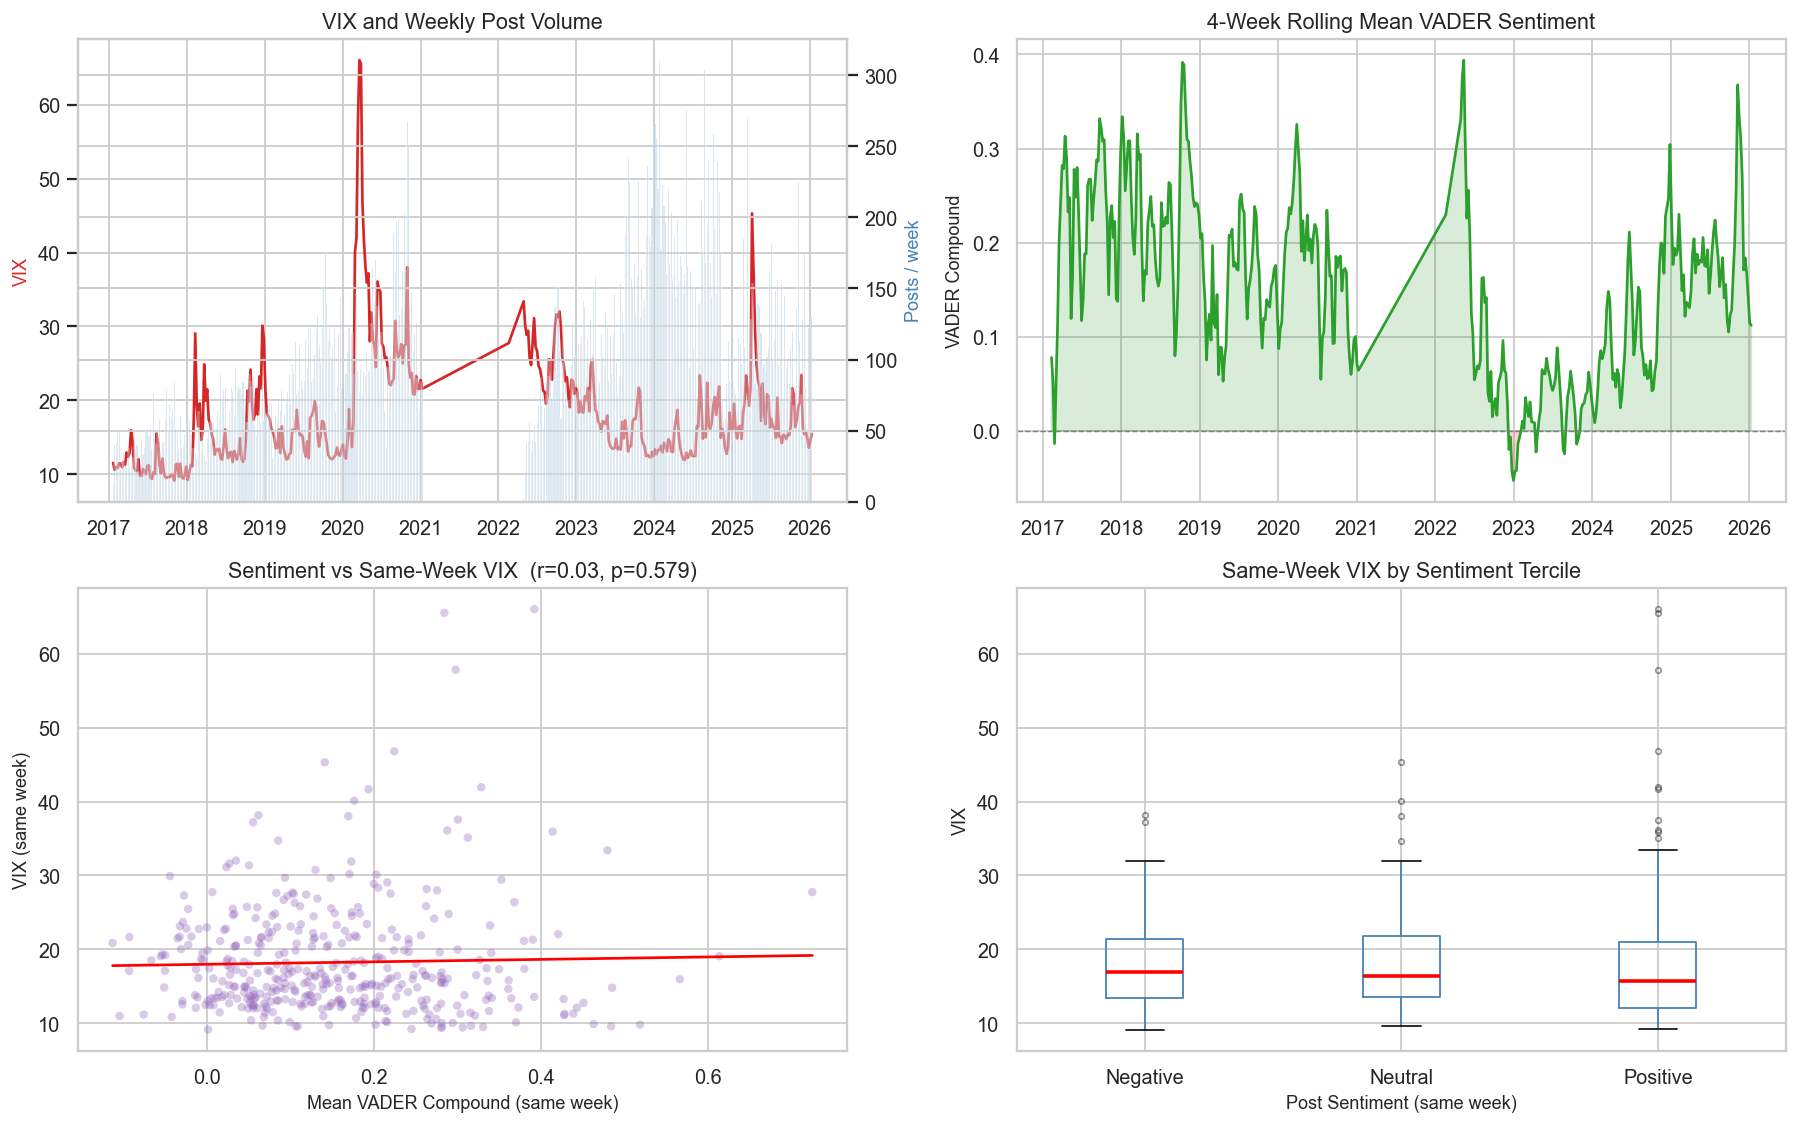

Saved: eda_plots.png
Correlation Matrix
                  tweet_count  mean_vader  frac_negative  mean_frac_caps  mean_exclamation  mean_retweets    vix  delta_vix    epu
tweet_count             1.000      -0.326         -0.305           0.331            -0.173         -0.401  0.070      0.022  0.077
mean_vader             -0.326       1.000         -0.365          -0.105             0.346          0.273  0.028      0.049  0.072
frac_negative          -0.305      -0.365          1.000          -0.195             0.205          0.423 -0.088     -0.058 -0.174
mean_frac_caps          0.331      -0.105         -0.195           1.000             0.103         -0.051  0.050      0.036 -0.013
mean_exclamation       -0.173       0.346          0.205           0.103             1.000          0.259  0.212     -0.060  0.299
mean_retweets          -0.401       0.273          0.423          -0.051             0.259          1.000  0.190      0.019  0.010
vix                     0.070       0.028  

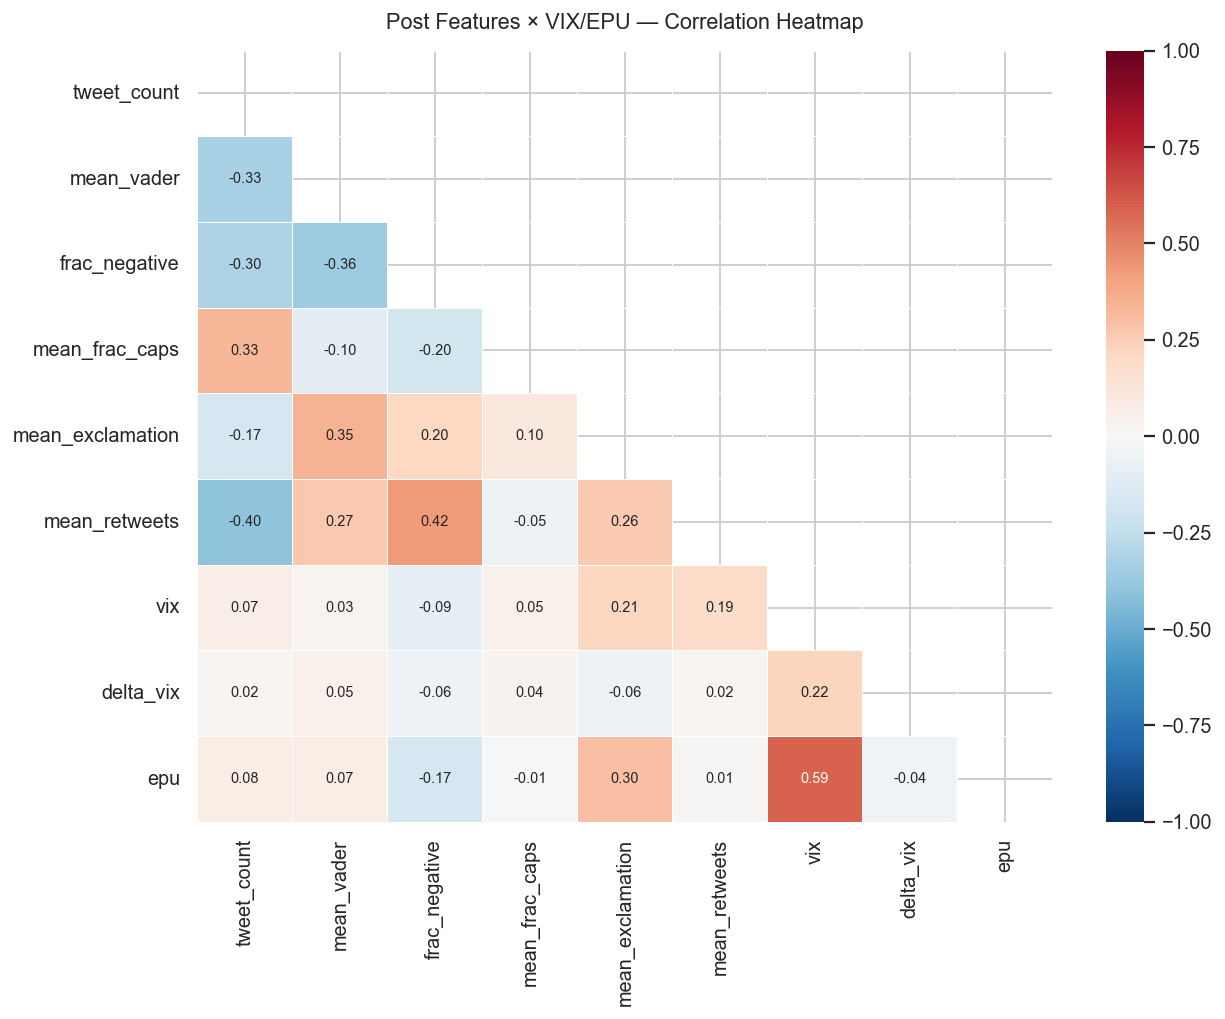

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Trump Posts & Market Volatility — EDA (Twitter + Truth Social)", fontsize=14, fontweight='bold')

import matplotlib.dates as mdates
from scipy import stats

# (a) VIX + tweet volume over time
ax = axes[0, 0]
ax2 = ax.twinx()
ax.plot(master['week_end'], master['vix'], color='#d62728', lw=1.5, label='VIX')
ax2.bar(master['week_end'], master['tweet_count'], alpha=0.25, color='steelblue', width=5)
ax.set_title('VIX and Weekly Post Volume')
ax.set_ylabel('VIX', color='#d62728')
ax2.set_ylabel('Posts / week', color='steelblue')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# (b) VADER sentiment rolling
ax = axes[0, 1]
roll = master.set_index('week_end')['mean_vader'].rolling(4).mean()
ax.plot(master['week_end'], roll.values, color='#2ca02c', lw=1.5)
ax.axhline(0, linestyle='--', color='grey', lw=0.8)
ax.fill_between(master['week_end'], roll.values, 0,
                where=(roll.values < 0), alpha=0.15, color='red')
ax.fill_between(master['week_end'], roll.values, 0,
                where=(roll.values > 0), alpha=0.15, color='green')
ax.set_title('4-Week Rolling Mean VADER Sentiment')
ax.set_ylabel('VADER Compound')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# (c) Scatter: VADER vs same-week VIX
ax = axes[1, 0]
plot_df = master[['mean_vader','vix']].dropna()
ax.scatter(plot_df['mean_vader'], plot_df['vix'],
           alpha=0.35, s=22, color='#9467bd', edgecolors='none')
m, b, r, p, _ = stats.linregress(plot_df['mean_vader'], plot_df['vix'])
xl = np.linspace(plot_df['mean_vader'].min(), plot_df['mean_vader'].max(), 100)
ax.plot(xl, m*xl+b, color='red', lw=1.5)
ax.set_xlabel('Mean VADER Compound (same week)')
ax.set_ylabel('VIX (same week)')
ax.set_title(f'Sentiment vs Same-Week VIX  (r={r:.2f}, p={p:.3f})')

# (d) VIX by sentiment tercile
ax = axes[1, 1]
master['sentiment_bin'] = pd.qcut(master['mean_vader'], 3,
                                    labels=['Negative','Neutral','Positive'])
master.boxplot(column='vix', by='sentiment_bin', ax=ax,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', lw=2),
               whiskerprops=dict(color='steelblue'),
               flierprops=dict(marker='o', markersize=3, alpha=0.4))
ax.set_title('Same-Week VIX by Sentiment Tercile')
ax.set_xlabel('Post Sentiment (same week)')
ax.set_ylabel('VIX')
plt.suptitle('')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: eda_plots.png")
'''

# ── Fix correlation table cell to use delta_vix not delta_vix_next ──
nb.cells[27].source = '''
corr_cols = ['tweet_count','mean_vader','frac_negative','mean_frac_caps',
             'mean_exclamation','mean_retweets','vix','delta_vix']
if 'epu' in master.columns:
    corr_cols.append('epu')

corr = master[corr_cols].corr().round(3)
print("Correlation Matrix")
print(corr.to_string())

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Post Features × VIX/EPU — Correlation Heatmap', pad=12)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Correlation Table — Tweet Features vs VIX

Correlation Matrix
                  tweet_count  mean_vader  frac_negative  mean_frac_caps  mean_exclamation  mean_retweets    vix  delta_vix    epu
tweet_count             1.000      -0.326         -0.305           0.331            -0.173         -0.401  0.070      0.022  0.077
mean_vader             -0.326       1.000         -0.365          -0.105             0.346          0.273  0.028      0.049  0.072
frac_negative          -0.305      -0.365          1.000          -0.195             0.205          0.423 -0.088     -0.058 -0.174
mean_frac_caps          0.331      -0.105         -0.195           1.000             0.103         -0.051  0.050      0.036 -0.013
mean_exclamation       -0.173       0.346          0.205           0.103             1.000          0.259  0.212     -0.060  0.299
mean_retweets          -0.401       0.273          0.423          -0.051             0.259          1.000  0.190      0.019  0.010
vix                     0.070       0.028         -0.088        

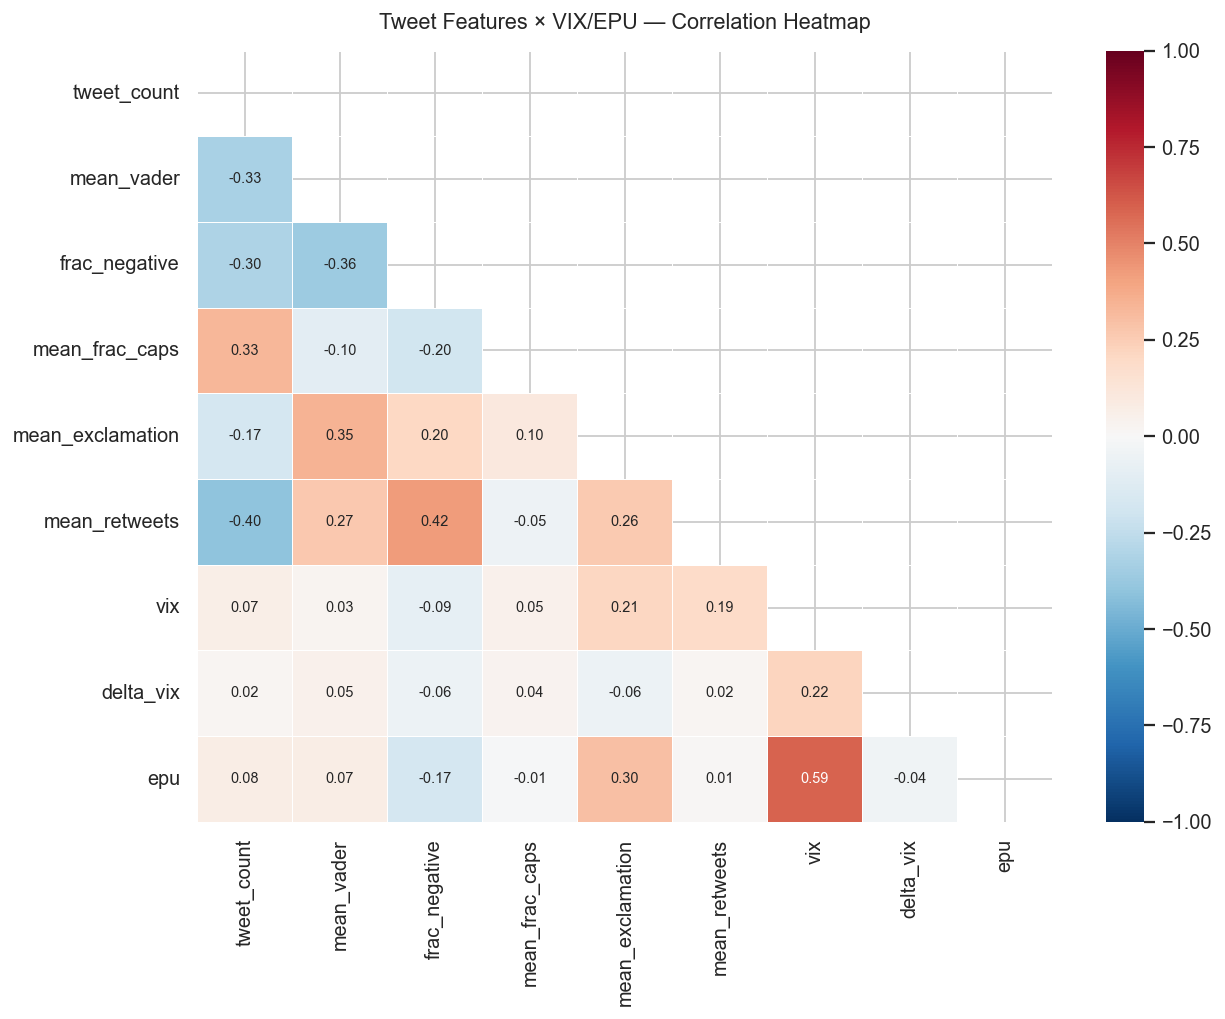

Saved: correlation_heatmap.png


In [19]:
corr_cols = ['tweet_count','mean_vader','frac_negative','mean_frac_caps',
             'mean_exclamation','mean_retweets','vix','delta_vix']
if 'epu' in master.columns:
    corr_cols.append('epu')

corr = master[corr_cols].corr().round(3)
print("Correlation Matrix")
print(corr.to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Tweet Features × VIX/EPU — Correlation Heatmap', pad=12)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: correlation_heatmap.png")


## 11. Save Master Dataset (for later notebooks)

In [20]:
master.to_csv('master_weekly.csv', index=False)
print(f"Saved master_weekly.csv — {len(master)} rows × {master.shape[1]} cols")
print("Columns:", list(master.columns))


Saved master_weekly.csv — 403 rows × 27 cols
Columns: ['week_end', 'tweet_count', 'mean_vader', 'std_vader', 'mean_vader_neg', 'mean_vader_pos', 'frac_negative', 'frac_positive', 'mean_frac_caps', 'mean_exclamation', 'mean_questions', 'mean_has_url', 'mean_mentions', 'mean_tweet_len', 'mean_retweets', 'mean_favorites', 'n_hashtags', 'vix', 'delta_vix', 'epu', 'delta_epu', 'fedfunds', 'unrate', 'sp500', 'sp500_ret', 'split', 'sentiment_bin']


## 12. Supervised Learning — Full Model Comparison

Predicts `delta_vix` (same-week VIX change) across 8 feature sets × 5 models, evaluated on a held-out temporal test set (2024–2026).

**Run cells 3b (FinBERT) before this section.**

In [21]:
# ── Cell A: Weekly FinBERT aggregation + PCA ──────────────────────────────
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

K_VALUES = [10, 75, 200]

print('Aggregating FinBERT embeddings to weekly level...')
embed_rows = []
for week_end, grp in df.groupby('week_end'):
    mean_vec = np.vstack(grp['finbert_embedding'].tolist()).mean(axis=0)
    embed_rows.append({'week_end': week_end, 'mean_embedding': mean_vec})
weekly_embeds = pd.DataFrame(embed_rows)
weekly_embeds['week_end'] = pd.to_datetime(weekly_embeds['week_end'])
print(f'  Weekly embedding matrix: {len(weekly_embeds)} weeks x 768 dims')

# Merge with master on week_end (inner — only weeks that have both VIX and tweets)
em = master[['week_end']].merge(weekly_embeds, on='week_end', how='inner').reset_index(drop=True)

# Derive train mask directly from TEST_START — no dependency on split column
train_mask = (em['week_end'] < TEST_START).values
E = np.vstack(em['mean_embedding'].values)   # (n_weeks, 768)
print(f'  Train weeks: {train_mask.sum()}  |  Test weeks: {(~train_mask).sum()}')

pc_cols = {}
for k in K_VALUES:
    scaler = StandardScaler()
    pca    = PCA(n_components=k, random_state=42)
    E_train_scaled = scaler.fit_transform(E[train_mask])
    E_all_scaled   = scaler.transform(E)
    pcs  = pca.fit(E_train_scaled).transform(E_all_scaled)
    cols = [f'finbert_pc{k}_{j+1}' for j in range(k)]
    pc_cols[k] = cols
    pc_df = pd.DataFrame(pcs, columns=cols, index=em.index)
    em    = pd.concat([em, pc_df], axis=1)
    var   = pca.explained_variance_ratio_.sum()
    print(f'  k={k:3d}: {var:.1%} variance explained')

# Merge PC columns into master
for k in K_VALUES:
    master_temp = master.merge(em[['week_end'] + pc_cols[k]], on='week_end', how='left')
    for col in pc_cols[k]:
        master[col] = master_temp[col].values

print(f'\nMaster shape after adding PC columns: {master.shape}')

Aggregating FinBERT embeddings to weekly level...
  Weekly embedding matrix: 403 weeks x 768 dims
  Train weeks: 297  |  Test weeks: 106
  k= 10: 82.0% variance explained
  k= 75: 97.2% variance explained
  k=200: 99.7% variance explained

Master shape after adding PC columns: (403, 312)


In [22]:
# ── Cell B: Feature set definitions ───────────────────────────────────────

# Ensure master is sorted before computing lag
master = master.sort_values('week_end').reset_index(drop=True)
master['delta_vix_lag1'] = master['delta_vix'].shift(1)

FEATS_1 = [
    'tweet_count', 'mean_vader', 'std_vader', 'mean_vader_neg', 'mean_vader_pos',
    'frac_negative', 'frac_positive', 'mean_frac_caps', 'mean_exclamation',
    'mean_questions', 'mean_has_url', 'mean_mentions',
    'mean_tweet_len', 'mean_retweets', 'mean_favorites', 'n_hashtags'
]

FEATURE_SETS = {
    'Set1':          FEATS_1,
    'Set1+AR(1)':    FEATS_1 + ['delta_vix_lag1'],
    'Set2 (k=10)':   pc_cols[10],
    'Set2 (k=75)':   pc_cols[75],
    'Set2 (k=200)':  pc_cols[200],
    'Set3 (k=10)':   FEATS_1 + pc_cols[10],
    'Set3 (k=75)':   FEATS_1 + pc_cols[75],
    'Set3 (k=200)':  FEATS_1 + pc_cols[200],
}

TARGET = 'delta_vix'

# Use split column if present, otherwise derive from TEST_START
if 'split' not in master.columns:
    master['split'] = np.where(master['week_end'] >= TEST_START, 'test', 'train')

print(f'Target: {TARGET}')
print(f'Train/test split: {(master["split"]=="train").sum()} train weeks, {(master["split"]=="test").sum()} test weeks')
print()
for name, cols in FEATURE_SETS.items():
    print(f'  {name:<18}: {len(cols):>3} features')

Target: delta_vix
Train/test split: 297 train weeks, 106 test weeks

  Set1              :  16 features
  Set1+AR(1)        :  17 features
  Set2 (k=10)       :  10 features
  Set2 (k=75)       :  75 features
  Set2 (k=200)      : 200 features
  Set3 (k=10)       :  26 features
  Set3 (k=75)       :  91 features
  Set3 (k=200)      : 216 features


In [23]:
# ── Cell C: Model loop ─────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

train_df = master[master['split'] == 'train'].copy()
test_df  = master[master['split'] == 'test'].copy()

MODELS = {
    'OLS':     lambda: LinearRegression(),
    'Ridge':   lambda: RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5),
    'Lasso':   lambda: LassoCV(alphas=np.logspace(-3, 1, 50), cv=5, max_iter=5000),
    'RF':      lambda: RandomForestRegressor(n_estimators=300, max_depth=5, random_state=42, n_jobs=-1),
    'XGBoost': lambda: XGBRegressor(n_estimators=300, max_depth=3, learning_rate=0.05,
                                     subsample=0.8, colsample_bytree=0.8,
                                     random_state=42, verbosity=0),
}
SCALE_MODELS = {'OLS', 'Ridge', 'Lasso'}

results = []
print(f'Running {len(FEATURE_SETS)} feature sets x {len(MODELS)} models...\n')

for feat_name, feat_cols in FEATURE_SETS.items():
    for model_name, model_fn in MODELS.items():
        needed = feat_cols + [TARGET]
        tr = train_df[needed].dropna()
        te = test_df[needed].dropna()
        if len(tr) < 10 or len(te) < 5:
            continue
        X_tr, y_tr = tr[feat_cols].values, tr[TARGET].values
        X_te, y_te = te[feat_cols].values, te[TARGET].values
        if model_name in SCALE_MODELS:
            sc = StandardScaler()
            X_tr = sc.fit_transform(X_tr)
            X_te = sc.transform(X_te)
        mdl = model_fn()
        mdl.fit(X_tr, y_tr)
        p_tr = mdl.predict(X_tr)
        p_te = mdl.predict(X_te)
        row = {
            'Feature Set': feat_name,
            'Model':       model_name,
            'Train R²':    round(r2_score(y_tr, p_tr), 4),
            'Test R²':     round(r2_score(y_te, p_te), 4),
            'Test RMSE':   round(np.sqrt(mean_squared_error(y_te, p_te)), 4),
            'Test MAE':    round(mean_absolute_error(y_te, p_te), 4),
            'N Train':     len(tr),
            'N Test':      len(te),
        }
        results.append(row)
        print(f'  {feat_name:<18} {model_name:<8} | Train R²={row["Train R²"]:>7.4f}  Test R²={row["Test R²"]:>7.4f}')

results_df = pd.DataFrame(results)
print(f'\nDone. {len(results_df)} total runs.')

Running 8 feature sets x 5 models...

  Set1               OLS      | Train R²= 0.0450  Test R²=-0.0056
  Set1               Ridge    | Train R²= 0.0094  Test R²=-0.0018
  Set1               Lasso    | Train R²= 0.0000  Test R²=-0.0002


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  Set1               RF       | Train R²= 0.4952  Test R²=-0.0008
  Set1               XGBoost  | Train R²= 0.9222  Test R²=-0.0699
  Set1+AR(1)         OLS      | Train R²= 0.0454  Test R²=-0.0009
  Set1+AR(1)         Ridge    | Train R²= 0.0097  Test R²=-0.0006
  Set1+AR(1)         Lasso    | Train R²= 0.0000  Test R²=-0.0001
  Set1+AR(1)         RF       | Train R²= 0.5110  Test R²= 0.0295
  Set1+AR(1)         XGBoost  | Train R²= 0.9345  Test R²=-0.0243
  Set2 (k=10)        OLS      | Train R²= 0.0132  Test R²=-0.0220
  Set2 (k=10)        Ridge    | Train R²= 0.0053  Test R²= 0.0010
  Set2 (k=10)        Lasso    | Train R²= 0.0000  Test R²=-0.0002
  Set2 (k=10)        RF       | Train R²= 0.5110  Test R²=-0.1391
  Set2 (k=10)        XGBoost  | Train R²= 0.9137  Test R²=-0.1363
  Set2 (k=75)        OLS      | Train R²= 0.1819  Test R²=-0.0800
  Set2 (k=75)        Ridge    | Train R²= 0.0722  Test R²= 0.0060
  Set2 (k=75)        Lasso    | Train R²= 0.0000  Test R²=-0.0002
  Set2 (k=

SUPERVISED LEARNING RESULTS — Target: delta_vix
 Feature Set   Model  Train R²  Test R²  Test RMSE  Test MAE  N Train  N Test
  Set1+AR(1)      RF    0.5110   0.0295     3.5909    2.2214      294     106
 Set3 (k=75)   Ridge    0.0784   0.0067     3.6328    2.2512      295     106
 Set2 (k=75)   Ridge    0.0722   0.0060     3.6340    2.2442      296     106
 Set2 (k=10)   Ridge    0.0053   0.0010     3.6433    2.2341      296     106
 Set3 (k=10)   Ridge    0.0141   0.0009     3.6434    2.2538      295     106
  Set1+AR(1)   Lasso    0.0000  -0.0001     3.6453    2.2395      294     106
 Set3 (k=75)   Lasso    0.0000  -0.0002     3.6453    2.2393      295     106
        Set1   Lasso    0.0000  -0.0002     3.6453    2.2393      295     106
 Set3 (k=10)   Lasso    0.0000  -0.0002     3.6453    2.2393      295     106
 Set2 (k=10)   Lasso    0.0000  -0.0002     3.6453    2.2394      296     106
Set3 (k=200)   Lasso    0.0000  -0.0002     3.6453    2.2393      295     106
Set2 (k=200)   L

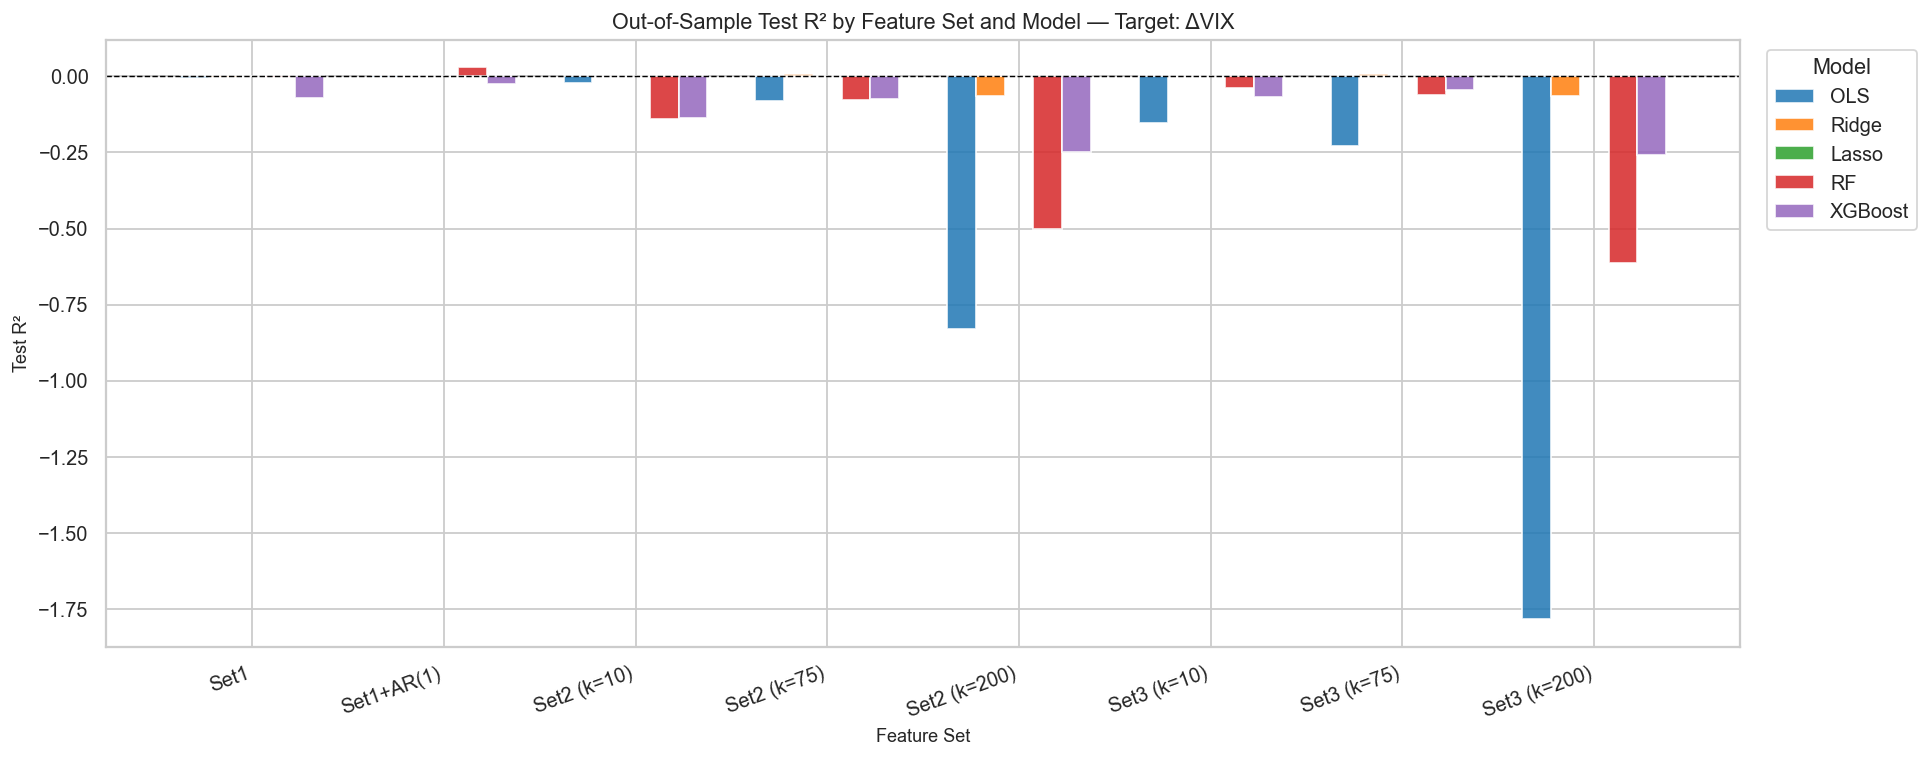

Saved: supervised_results.png


In [24]:
# ── Cell D: Results table + bar chart ─────────────────────────────────────

print('SUPERVISED LEARNING RESULTS — Target: delta_vix')
print('='*75)
print(results_df.sort_values('Test R²', ascending=False).to_string(index=False))

# Grouped bar chart — Test R² by feature set and model
feat_order  = list(FEATURE_SETS.keys())
model_order = list(MODELS.keys())
x     = np.arange(len(feat_order))
width = 0.15
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

fig, ax = plt.subplots(figsize=(15, 6))
for i, model_name in enumerate(model_order):
    sub = results_df[results_df['Model'] == model_name].set_index('Feature Set')
    r2s = [sub.loc[fs, 'Test R²'] if fs in sub.index else 0 for fs in feat_order]
    ax.bar(x + i * width, r2s, width, label=model_name, color=colors[i], alpha=0.85)

ax.axhline(0, color='black', lw=0.8, linestyle='--')
ax.set_xlabel('Feature Set')
ax.set_ylabel('Test R²')
ax.set_title('Out-of-Sample Test R² by Feature Set and Model — Target: ΔVIX')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(feat_order, rotation=20, ha='right')
ax.legend(title='Model', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('supervised_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: supervised_results.png')